# Semana 8



#  0



In [1]:
from pathlib import Path
from datetime import datetime
import json
import time
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    TimeSeriesSplit,
    StratifiedKFold,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    make_scorer
)
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, randint

import joblib

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

START_DATE = "2025-07-01"
END_DATE = "2026-05-08"

PROJECT_ROOT = Path(r"C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MARKET_DIR = DATA_DIR / "market"
FIGS_DIR = PROJECT_ROOT / "figs"
LOGS_DIR = PROJECT_ROOT / "logs"
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "artifacts"

FIGS_DIR.mkdir(exist_ok=True, parents=True)
LOGS_DIR.mkdir(exist_ok=True, parents=True)
ARTIFACTS_DIR.mkdir(exist_ok=True, parents=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seed:", RANDOM_SEED)

PROJECT_ROOT: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline
Python: 3.12.7
Pandas: 3.0.2
NumPy: 2.1.2
Seed: 42


# 1 Carga de datos

En esta etapa se cargan los datasets generados por el pipeline de procesamiento de noticias y mercado.

Los datos incluyen:

- Noticias limpias (`news_clean.csv`)
- Resultados de análisis de sentimiento (`news_scores.csv`)
- Indicadores diarios agregados (`daily_sentiment.csv`)
- Comparación sentimiento vs USD/PEN (`compare_sentiment_vs_fx.csv`)
- Tabla de evaluación diaria (`daily_evaluation_table.csv`)
- Serie histórica de USD/PEN (`usdpen_yahoo.csv`)

El objetivo es disponer de una única fuente consolidada para construir el dataset de modelado.

In [2]:
files = {
    "news_clean": PROCESSED_DIR / "news_clean.csv",
    "news_scores": PROCESSED_DIR / "news_scores.csv",
    "daily_sentiment": PROCESSED_DIR / "daily_sentiment.csv",
    "compare_fx": PROCESSED_DIR / "compare_sentiment_vs_fx.csv",
    "daily_eval": PROCESSED_DIR / "daily_evaluation_table.csv",
    "usdpen": MARKET_DIR / "usdpen_yahoo.csv",
}

datasets = {}

for name, path in files.items():
    if path.exists():
        df = pd.read_csv(path)
        datasets[name] = df
        print(f"✓ Cargado: {path.relative_to(PROJECT_ROOT)} | shape={df.shape}")
    else:
        print(f"⚠ No encontrado: {path.relative_to(PROJECT_ROOT)}")

compare_fx = datasets["compare_fx"]
daily_sentiment = datasets["daily_sentiment"]

✓ Cargado: data\processed\news_clean.csv | shape=(2906, 10)
✓ Cargado: data\processed\news_scores.csv | shape=(2849, 7)
✓ Cargado: data\processed\daily_sentiment.csv | shape=(122, 8)
✓ Cargado: data\processed\compare_sentiment_vs_fx.csv | shape=(90, 13)
✓ Cargado: data\processed\daily_evaluation_table.csv | shape=(90, 6)
✓ Cargado: data\market\usdpen_yahoo.csv | shape=(223, 7)


# 2. Control de calidad y versionado

Antes de iniciar el modelado se verifica la integridad de los datos.

Se realizan controles sobre:

- Cantidad de filas y columnas.
- Valores nulos.
- Duplicados.
- Consistencia de identificadores.
- Fechas disponibles.

Además se genera un snapshot de versionado para garantizar reproducibilidad y trazabilidad de los experimentos.

El resultado de esta etapa queda almacenado en los logs del proyecto.

In [3]:
snapshot = {
    "generated_at": datetime.now().isoformat(),
    "start_date": START_DATE,
    "end_date": END_DATE,
    "random_seed": RANDOM_SEED,
    "files": {}
}

for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Columnas:", df.columns.tolist())
    
    nulls = df.isnull().sum().sort_values(ascending=False)
    print("Nulos principales:")
    print(nulls[nulls > 0].head(10))
    
    snapshot["files"][name] = {
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "column_names": df.columns.tolist()
    }

snapshot_path = LOGS_DIR / "week8_data_snapshot.json"

with open(snapshot_path, "w", encoding="utf-8") as f:
    json.dump(snapshot, f, indent=2, ensure_ascii=False)

print("Snapshot guardado:", snapshot_path)


=== news_clean ===
Shape: (2906, 10)
Columnas: ['news_id', 'source', 'url', 'published_at', 'fetched_at', 'title_raw', 'body_raw', 'content_hash', 'lang_hint', 'reliability_weight']
Nulos principales:
body_raw        57
published_at    12
title_raw        5
dtype: int64

=== news_scores ===
Shape: (2849, 7)
Columnas: ['news_id', 'sentiment_model', 'sentiment_label', 'p_pos', 'p_neu', 'p_neg', 'language']
Nulos principales:
Series([], dtype: int64)

=== daily_sentiment ===
Shape: (122, 8)
Columnas: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu']
Nulos principales:
Series([], dtype: int64)

=== compare_fx ===
Shape: (90, 13)
Columnas: ['date', 'asset', 'n_news_total', 'sent_index_mean', 'sent_index_strength', 'share_pos', 'share_neg', 'share_neu', 'open', 'close', 'signal', 'real_dir', 'hit']
Nulos principales:
Series([], dtype: int64)

=== daily_eval ===
Shape: (90, 6)
Columnas: ['Fecha', 'Señal Sentimiento', 'Apertura'

# 3. Preparación del dataset diario

Se construye el dataset diario unificando información de sentimiento y mercado.

La variable objetivo utilizada es:

target_up

donde:

- 1 → USD/PEN sube
- 0 → USD/PEN no sube

También se incorporan variables derivadas del mercado:

- variación diaria del tipo de cambio
- retorno porcentual
- dirección observada

Esta tabla constituye la base para todos los experimentos posteriores.

In [4]:
df_daily = compare_fx.copy()

df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce")
df_daily = df_daily.dropna(subset=["date"])

df_daily = df_daily[
    (df_daily["date"] >= pd.to_datetime(START_DATE)) &
    (df_daily["date"] <= pd.to_datetime(END_DATE))
].copy()

df_daily = df_daily.sort_values("date").reset_index(drop=True)

numeric_cols = [
    "n_news_total",
    "sent_index_mean",
    "sent_index_strength",
    "share_pos",
    "share_neg",
    "share_neu",
    "open",
    "close"
]

for col in numeric_cols:
    if col in df_daily.columns:
        df_daily[col] = pd.to_numeric(df_daily[col], errors="coerce")

if "real_dir" not in df_daily.columns:
    df_daily["real_dir"] = np.where(df_daily["close"] > df_daily["open"], "UP", "DOWN")

df_daily["target_up"] = (df_daily["real_dir"] == "UP").astype(int)
df_daily["fx_diff"] = df_daily["close"] - df_daily["open"]
df_daily["fx_return"] = df_daily["fx_diff"] / df_daily["open"]

print("Fechas:")
print(df_daily["date"].min(), "→", df_daily["date"].max())
print("Shape:", df_daily.shape)
print(df_daily["target_up"].value_counts())
display(df_daily.head())

Fechas:
2025-07-03 00:00:00 → 2026-05-08 00:00:00
Shape: (90, 16)
target_up
0    49
1    41
Name: count, dtype: int64


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,signal,real_dir,hit,target_up,fx_diff,fx_return
0,2025-07-03,USD/PEN,28,0.115051,0.086935,0.035714,0.0,0.964286,3.484046,3.484046,UP,FLAT,0,0,0.0,0.0
1,2025-07-07,USD/PEN,27,0.167342,0.109434,0.037037,0.0,0.962963,3.477862,3.477862,UP,FLAT,0,0,0.0,0.0
2,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286,3.542000,3.542000,UP,FLAT,0,0,0.0,0.0
3,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034,3.476722,3.476722,UP,FLAT,0,0,0.0,0.0
4,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143,3.560500,3.560500,UP,FLAT,0,0,0.0,0.0


# 4. Análisis inicial del dataset

Se realiza una exploración descriptiva del conjunto de datos.

Se analiza:

- distribución temporal
- cantidad de observaciones
- balance de clases
- comportamiento de las variables de sentimiento

Resultados observados:

- 90 observaciones disponibles.
- Distribución relativamente balanceada del target.
- Existencia de señales de sentimiento positivas, negativas y neutrales.

Este análisis permite validar que el dataset es apto para experimentación supervisada.

In [5]:
df_model = df_daily.copy()
df_model = df_model.sort_values("date").reset_index(drop=True)

df_model["lag_sent_1"] = df_model["sent_index_mean"].shift(1)
df_model["lag_sent_2"] = df_model["sent_index_mean"].shift(2)
df_model["lag_sent_3"] = df_model["sent_index_mean"].shift(3)

df_model["rolling_sent_3"] = df_model["sent_index_mean"].rolling(3).mean()
df_model["rolling_sent_5"] = df_model["sent_index_mean"].rolling(5).mean()

df_model["volatility_sent_3"] = df_model["sent_index_mean"].rolling(3).std()
df_model["volatility_sent_5"] = df_model["sent_index_mean"].rolling(5).std()

df_model["lag_news_1"] = df_model["n_news_total"].shift(1)

df_model["lag_share_pos_1"] = df_model["share_pos"].shift(1)
df_model["lag_share_neg_1"] = df_model["share_neg"].shift(1)
df_model["lag_share_neu_1"] = df_model["share_neu"].shift(1)

required_cols = [
    "target_up",
    "lag_sent_1",
    "lag_sent_2",
    "rolling_sent_3",
    "volatility_sent_3"
]

df_model = df_model.dropna(subset=required_cols).reset_index(drop=True)

print("Dataset modelado:", df_model.shape)
display(df_model.head())

Dataset modelado: (88, 27)


,date,asset,n_news_total,sent_index_mean,sent_index_strength,share_pos,share_neg,share_neu,open,close,...,lag_sent_2,lag_sent_3,rolling_sent_3,rolling_sent_5,volatility_sent_3,volatility_sent_5,lag_news_1,lag_share_pos_1,lag_share_neg_1,lag_share_neu_1
0,2025-07-09,USD/PEN,28,0.106546,0.081561,0.035714,0.0,0.964286,3.542000,3.542000,...,0.115051,NaN,0.129646,NaN,0.032921,NaN,27.0,0.037037,0.0,0.962963
1,2025-07-14,USD/PEN,29,0.152271,0.106098,0.068966,0.0,0.931034,3.476722,3.476722,...,0.167342,0.115051,0.142053,NaN,0.031660,NaN,28.0,0.035714,0.0,0.964286
2,2025-07-16,USD/PEN,28,0.189611,0.134425,0.142857,0.0,0.857143,3.560500,3.560500,...,0.106546,0.167342,0.149476,0.146164,0.041603,0.035039,29.0,0.068966,0.0,0.931034
3,2025-07-17,USD/PEN,29,0.105031,0.079039,0.068966,0.0,0.931034,3.544500,3.544500,...,0.152271,0.106546,0.148971,0.144160,0.042386,0.037466,28.0,0.142857,0.0,0.857143
4,2025-07-22,USD/PEN,29,0.136440,0.098304,0.068966,0.0,0.931034,3.559000,3.559000,...,0.189611,0.152271,0.143694,0.137980,0.042754,0.035164,29.0,0.068966,0.0,0.931034


# 5. Definición de experimentos A/B

Se diseñan experimentos comparables siguiendo el principio de un cambio por variante.

Experimentos evaluados:

### Baseline_lag1

Utiliza únicamente:

- lag_sent_1

Representa la referencia mínima del sistema.

### Var1_lag1_lag2

Agrega:

- lag_sent_2

Objetivo:
evaluar si existe memoria temporal adicional en el sentimiento.

### Var2_lags_volume_shares

Agrega:

- volumen de noticias
- proporción positiva
- proporción negativa
- proporción neutral

Objetivo:
evaluar si la intensidad informativa aporta capacidad predictiva.

### Var3_full_temporal

Agrega además:

- rolling_sent_3
- volatility_sent_3

Objetivo:
capturar tendencia y estabilidad temporal del sentimiento.

In [6]:
experiments = [
    {
        "model": "Baseline_lag1",
        "features": ["lag_sent_1"],
        "description": "Sentimiento del día anterior"
    },
    {
        "model": "Var1_lag1_lag2",
        "features": ["lag_sent_1", "lag_sent_2"],
        "description": "Memoria temporal de dos días"
    },
    {
        "model": "Var2_lags_volume_shares",
        "features": [
            "lag_sent_1",
            "lag_sent_2",
            "n_news_total",
            "share_pos",
            "share_neg",
            "share_neu"
        ],
        "description": "Sentimiento + volumen + composición"
    },
    {
        "model": "Var3_full_temporal",
        "features": [
            "lag_sent_1",
            "lag_sent_2",
            "rolling_sent_3",
            "volatility_sent_3",
            "n_news_total",
            "share_pos",
            "share_neg",
            "share_neu"
        ],
        "description": "Variables temporales completas"
    }
]

for exp in experiments:
    print(exp["model"], "→", exp["features"])

Baseline_lag1 → ['lag_sent_1']
Var1_lag1_lag2 → ['lag_sent_1', 'lag_sent_2']
Var2_lags_volume_shares → ['lag_sent_1', 'lag_sent_2', 'n_news_total', 'share_pos', 'share_neg', 'share_neu']
Var3_full_temporal → ['lag_sent_1', 'lag_sent_2', 'rolling_sent_3', 'volatility_sent_3', 'n_news_total', 'share_pos', 'share_neg', 'share_neu']


# 6. Feature Engineering Temporal

Se construyen variables temporales utilizando exclusivamente información disponible en fechas anteriores.

El objetivo es capturar memoria, tendencia y volatilidad del sentimiento.

Variables creadas:

| Variable | Significado |
|-----------|-----------|
| lag_sent_1 | sentimiento del día anterior |
| lag_sent_2 | sentimiento de hace 2 días |
| lag_sent_3 | sentimiento de hace 3 días |
| rolling_sent_3 | promedio móvil de sentimiento |
| rolling_sent_5 | promedio móvil de 5 días |
| volatility_sent_3 | volatilidad reciente |
| volatility_sent_5 | volatilidad de 5 días |
| lag_news_1 | volumen de noticias anterior |
| lag_share_pos_1 | proporción positiva anterior |
| lag_share_neg_1 | proporción negativa anterior |
| lag_share_neu_1 | proporción neutral anterior |

Todas las variables fueron construidas mediante operaciones `shift()` para evitar leakage temporal.

In [8]:
TEST_SIZE_RATIO = 0.30
split_idx = int(len(df_model) * (1 - TEST_SIZE_RATIO))

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

print("Train:", train_df["date"].min(), "→", train_df["date"].max(), "| filas:", len(train_df))
print("Test :", test_df["date"].min(), "→", test_df["date"].max(), "| filas:", len(test_df))

print("\nDistribución train:")
print(train_df["target_up"].value_counts())

print("\nDistribución test:")
print(test_df["target_up"].value_counts())

Train: 2025-07-09 00:00:00 → 2026-03-05 00:00:00 | filas: 61
Test : 2026-03-06 00:00:00 → 2026-05-08 00:00:00 | filas: 27

Distribución train:
target_up
0    39
1    22
Name: count, dtype: int64

Distribución test:
target_up
1    19
0     8
Name: count, dtype: int64


# 7. Split temporal y validación

Se utiliza una separación temporal estricta entre entrenamiento y prueba.

Train:

- 2025-07-09 → 2026-03-05
- 61 observaciones

Test:

- 2026-03-06 → 2026-05-08
- 27 observaciones

Este esquema reproduce un escenario real de predicción financiera donde únicamente se dispone de información histórica para entrenar.

## Control de leakage

Se garantiza que:

- No se utilizan datos futuros.
- Las features temporales usan únicamente información pasada.
- El escalado y ajuste de modelos se realizan exclusivamente sobre train.

## Validación complementaria

Además del holdout temporal, se incorpora:

- TimeSeriesSplit
- StratifiedKFold

con el objetivo de evaluar estabilidad y robustez de los resultados.

In [10]:
def make_logreg(C=1.0, penalty="l2", class_weight="balanced", solver="liblinear"):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            class_weight=class_weight,
            max_iter=1000,
            random_state=RANDOM_SEED
        ))
    ])


def evaluate_predictions(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_binary": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score)
    }


def evaluate_model_holdout(model, X_train, y_train, X_test, y_test):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_predictions(y_test, y_pred, y_score)
    metrics["elapsed_seconds"] = elapsed
    
    return metrics, y_pred, y_score, model

# 8. Experimentos A/B

Se realizó una comparación controlada entre distintas variantes de features.

Cada variante introduce únicamente un cambio respecto a la anterior para aislar el efecto de cada conjunto de variables.

Experimentos evaluados:

| Modelo | Descripción |
|----------|----------|
| Baseline_lag1 | Sentimiento del día anterior |
| Var1_lag1_lag2 | Agrega memoria temporal de 2 días |
| Var2_lags_volume_shares | Agrega volumen y composición del sentimiento |
| Var3_full_temporal | Agrega tendencia y volatilidad temporal |

La métrica principal utilizada fue PR-AUC, mientras que F1 Binary se utilizó como métrica secundaria.

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

stratified_rows = []

for exp in experiments:
    model_name = exp["model"]
    features = exp["features"]
    
    X = df_model[features].copy()
    y = df_model["target_up"].astype(int).copy()
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[train_idx]
        X_te = X.iloc[test_idx]
        y_tr = y.iloc[train_idx]
        y_te = y.iloc[test_idx]
        
        model = make_logreg()
        
        start = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - start
        
        y_pred = model.predict(X_te)
        y_score = model.predict_proba(X_te)[:, 1]
        
        stratified_rows.append({
            "model": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_te, y_pred),
            "f1_binary": f1_score(y_te, y_pred, zero_division=0),
            "precision": precision_score(y_te, y_pred, zero_division=0),
            "recall": recall_score(y_te, y_pred, zero_division=0),
            "pr_auc": average_precision_score(y_te, y_score),
            "elapsed_seconds": elapsed,
            "n_train": len(y_tr),
            "n_test": len(y_te),
            "train_class_0": int((y_tr == 0).sum()),
            "train_class_1": int((y_tr == 1).sum()),
            "test_class_0": int((y_te == 0).sum()),
            "test_class_1": int((y_te == 1).sum()),
        })

stratified_cv_df = pd.DataFrame(stratified_rows)
display(stratified_cv_df)

stratified_cv_summary = (
    stratified_cv_df
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_binary_mean=("f1_binary", "mean"),
        f1_binary_std=("f1_binary", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        elapsed_mean=("elapsed_seconds", "mean"),
        folds=("fold", "count")
    )
    .reset_index()
)

display(stratified_cv_summary)

stratified_cv_df.to_csv(LOGS_DIR / "week8_stratified_cv_folds.csv", index=False, encoding="utf-8-sig")
stratified_cv_summary.to_csv(LOGS_DIR / "week8_stratified_cv_summary.csv", index=False, encoding="utf-8-sig")

,model,fold,accuracy,f1_binary,precision,recall,pr_auc,elapsed_seconds,n_train,n_test,train_class_0,train_class_1,test_class_0,test_class_1
0,Baseline_lag1,1,0.555556,0.428571,0.500000,0.375000,0.639637,0.006003,70,18,37,33,10,8
1,Baseline_lag1,2,0.611111,0.588235,0.555556,0.625000,0.731182,0.002665,70,18,37,33,10,8
2,Baseline_lag1,3,0.555556,0.428571,0.600000,0.333333,0.560714,0.001588,70,18,38,32,9,9
3,Baseline_lag1,4,0.529412,0.500000,0.500000,0.500000,0.570960,0.002098,71,17,38,33,9,8
4,Baseline_lag1,5,0.588235,0.588235,0.555556,0.625000,0.728400,0.002087,71,17,38,33,9,8
5,Var1_lag1_lag2,1,0.666667,0.571429,0.666667,0.500000,0.726532,0.001998,70,18,37,33,10,8
6,Var1_lag1_lag2,2,0.666667,0.666667,0.600000,0.750000,0.825379,0.002091,70,18,37,33,10,8
7,Var1_lag1_lag2,3,0.555556,0.500000,0.571429,0.444444,0.503307,0.001999,70,18,38,32,9,9
8,Var1_lag1_lag2,4,0.588235,0.461538,0.600000,0.375000,0.487990,0.002011,71,17,38,33,9,8
9,Var1_lag1_lag2,5,0.705882,0.705882,0.666667,0.750000,0.853869,0.001994,71,17,38,33,9,8


,model,accuracy_mean,accuracy_std,f1_binary_mean,f1_binary_std,precision_mean,recall_mean,pr_auc_mean,pr_auc_std,elapsed_mean,folds
0,Baseline_lag1,0.567974,0.031886,0.506723,0.079920,0.542222,0.491667,0.646179,0.082144,0.002888,5
1,Var1_lag1_lag2,0.636601,0.062280,0.581103,0.104712,0.620952,0.563889,0.679415,0.174368,0.002019,5
2,Var2_lags_volume_shares,0.566667,0.117343,0.449744,0.176081,0.538571,0.391667,0.650522,0.141802,0.001618,5
3,Var3_full_temporal,0.554902,0.117588,0.429091,0.157439,0.564286,0.366667,0.660207,0.148950,0.002201,5


# 9. Validación estratificada (Stratified K-Fold)

Como validación complementaria se incorporó Stratified K-Fold.

Objetivo:

- Mantener la proporción de clases UP y DOWN en cada fold.
- Reducir la varianza de la evaluación.
- Verificar que los resultados no dependan de una única partición.

Configuración utilizada:

- n_splits = 5
- shuffle = True
- random_state fijo

Distribución observada:

- Clase DOWN = 47
- Clase UP = 41

Por lo tanto, el dataset presenta un balance razonable para aplicar validación estratificada.

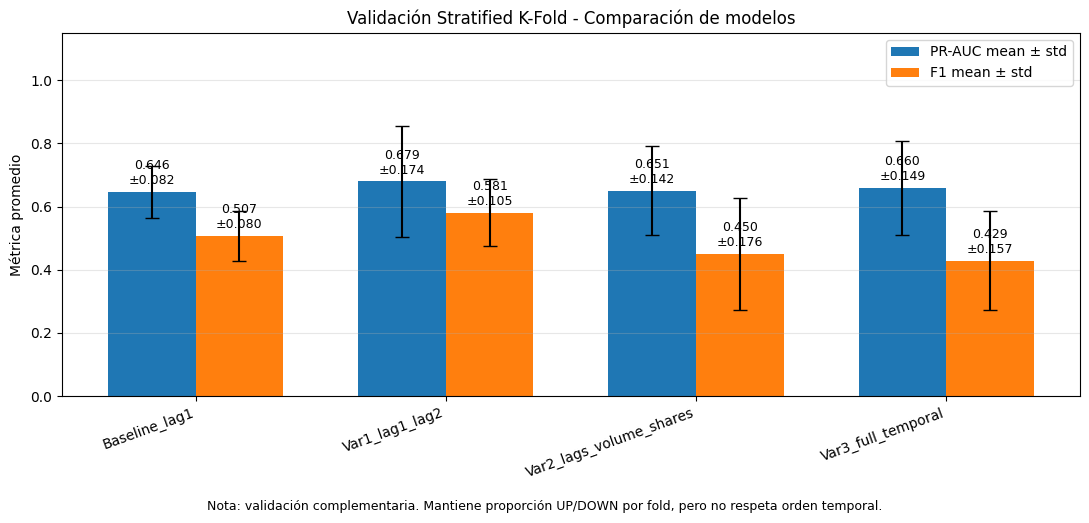

In [12]:
plot_skf = stratified_cv_summary.copy()

order_models = [
    "Baseline_lag1",
    "Var1_lag1_lag2",
    "Var2_lags_volume_shares",
    "Var3_full_temporal"
]

plot_skf["model"] = pd.Categorical(plot_skf["model"], categories=order_models, ordered=True)
plot_skf = plot_skf.sort_values("model").reset_index(drop=True)

x = np.arange(len(plot_skf))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars_pr = ax.bar(
    x - bar_width / 2,
    plot_skf["pr_auc_mean"],
    yerr=plot_skf["pr_auc_std"],
    width=bar_width,
    label="PR-AUC mean ± std",
    capsize=5
)

bars_f1 = ax.bar(
    x + bar_width / 2,
    plot_skf["f1_binary_mean"],
    yerr=plot_skf["f1_binary_std"],
    width=bar_width,
    label="F1 mean ± std",
    capsize=5
)

for i, bar in enumerate(bars_pr):
    h = bar.get_height()
    s = plot_skf.loc[i, "pr_auc_std"]
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.025, f"{h:.3f}\n±{s:.3f}", ha="center", fontsize=9)

for i, bar in enumerate(bars_f1):
    h = bar.get_height()
    s = plot_skf.loc[i, "f1_binary_std"]
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.025, f"{h:.3f}\n±{s:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_skf["model"], rotation=20, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Métrica promedio")
ax.set_title("Validación Stratified K-Fold - Comparación de modelos")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.text(
    0.5,
    -0.03,
    "Nota: validación complementaria. Mantiene proporción UP/DOWN por fold, pero no respeta orden temporal.",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.savefig(FIGS_DIR / "week8_stratified_cv_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 10. Resultados de Stratified K-Fold

La comparación de modelos se realizó utilizando el promedio y desviación estándar de las métricas obtenidas en los 5 folds.

Resultados principales:

| Modelo | PR-AUC promedio | F1 promedio |
|----------|----------|----------|
| Baseline_lag1 | 0.646 | 0.507 |
| Var1_lag1_lag2 | 0.679 | 0.581 |
| Var2_lags_volume_shares | 0.651 | 0.450 |
| Var3_full_temporal | 0.660 | 0.429 |

Observaciones:

- Var1_lag1_lag2 obtuvo el mejor desempeño promedio.
- Agregar únicamente lag_sent_2 genera una mejora consistente.
- Las variantes más complejas no lograron superar a Var1.
- Esto sugiere que la memoria temporal corta contiene información útil para la predicción.

In [ ]:
# =========================
# 
# =========================

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import average_precision_score
from scipy.stats import loguniform, randint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

best_features = ["lag_sent_1", "lag_sent_2"]

X = df_model[best_features].copy()
y = df_model["target_up"].astype(int).copy()

min_class_count = y.value_counts().min()
n_splits_safe = min(5, min_class_count)

print("Distribución target:")
print(y.value_counts())
print("n_splits usado:", n_splits_safe)

skf_search = StratifiedKFold(
    n_splits=n_splits_safe,
    shuffle=True,
    random_state=RANDOM_SEED
)

# Scorer robusto para PR-AUC
def pr_auc_estimator_scorer(estimator, X_val, y_val):
    y_score = estimator.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_score)

Distribución target:
target_up
0    47
1    41
Name: count, dtype: int64
n_splits usado: 5


# 11. Optimización de hiperparámetros (Random Search)

Se implementó una búsqueda aleatoria de hiperparámetros para explorar configuraciones potencialmente superiores a las utilizadas inicialmente.

Modelos optimizados:

- Logistic Regression
- Random Forest

Configuración:

- 30 configuraciones aleatorias por modelo.
- Validación interna mediante Stratified K-Fold.
- Métrica objetivo: PR-AUC.

Esta etapa permite identificar automáticamente configuraciones con mejor capacidad predictiva.

In [26]:
# =========================
# =========================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_SEED
    ))
])

param_dist_lr = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"]
}

random_search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist_lr,
    n_iter=30,
    scoring=pr_auc_estimator_scorer,
    cv=skf_search,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_lr.fit(X, y)

print("Mejor score LR:", random_search_lr.best_score_)
print("Mejores parámetros LR:")
print(random_search_lr.best_params_)

lr_results = pd.DataFrame(random_search_lr.cv_results_)
lr_results["model_family"] = "LogisticRegression"

lr_results.to_csv(
    LOGS_DIR / "week8_random_search_logistic_results.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    lr_results[[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "params"
    ]].sort_values("rank_test_score").head(10)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejor score LR: 0.6825241593011201
Mejores parámetros LR:
{'clf__C': np.float64(0.03334792728637585), 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
23,1,0.682524,0.172739,0.005039,"{'clf__C': 0.03618723330959624, 'clf__class_we..."
18,1,0.682524,0.172739,0.004735,"{'clf__C': 0.03334792728637585, 'clf__class_we..."
5,3,0.681198,0.171631,0.006835,"{'clf__C': 0.001267425589893723, 'clf__class_w..."
13,3,0.681198,0.171631,0.004326,"{'clf__C': 0.009962513222055111, 'clf__class_w..."
22,3,0.681198,0.171631,0.004829,"{'clf__C': 0.01967432802530612, 'clf__class_we..."
20,3,0.681198,0.171631,0.002824,"{'clf__C': 0.00407559644007287, 'clf__class_we..."
28,3,0.681198,0.171631,0.005750,"{'clf__C': 0.0027698899227562817, 'clf__class_..."
10,8,0.679415,0.155960,0.004974,"{'clf__C': 1.1462107403425035, 'clf__class_wei..."
19,9,0.678454,0.157147,0.004724,"{'clf__C': 2.6373339933815254, 'clf__class_wei..."
15,9,0.678454,0.157147,0.004785,"{'clf__C': 1.0907475835157696, 'clf__class_wei..."


# 12. Resultados de Random Search

Mejores resultados encontrados:

## Logistic Regression

PR-AUC CV:

0.683

Parámetros destacados:

- Penalización L2
- Regularización optimizada mediante búsqueda aleatoria

## Random Forest

PR-AUC CV:

0.692

Parámetros destacados:

- max_depth = 4
- n_estimators = 54
- min_samples_split = 4

Conclusión:

Random Forest superó ligeramente a Logistic Regression y obtuvo la mejor métrica central del proceso de optimización.

In [21]:
# =========================
# 12. Random Search - Random Forest
# =========================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

param_dist_rf = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(2, 10),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring=pr_auc_estimator_scorer,
    cv=skf_search,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

random_search_rf.fit(X, y)

print("Mejor score RF:", random_search_rf.best_score_)
print("Mejores parámetros RF:")
print(random_search_rf.best_params_)

rf_results = pd.DataFrame(random_search_rf.cv_results_)
rf_results["model_family"] = "RandomForest"

rf_results.to_csv(
    LOGS_DIR / "week8_random_search_rf_results.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    rf_results[[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "params"
    ]].sort_values("rank_test_score").head(10)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejor score RF: 0.6920481068949206
Mejores parámetros RF:
{'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 54}


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params
27,1,0.692048,0.159863,0.111096,"{'max_depth': 4, 'max_features': None, 'min_sa..."
13,2,0.687654,0.153973,1.831497,"{'max_depth': 3, 'max_features': 'sqrt', 'min_..."
5,3,0.679651,0.167993,0.168824,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
12,4,0.676916,0.117951,2.242126,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
16,5,0.674794,0.124012,0.338418,"{'max_depth': 5, 'max_features': 'log2', 'min_..."
25,6,0.674598,0.128663,0.443074,"{'max_depth': 9, 'max_features': 'sqrt', 'min_..."
0,7,0.673621,0.122475,0.196464,"{'max_depth': 8, 'max_features': 'sqrt', 'min_..."
17,8,0.672291,0.126108,0.572199,"{'max_depth': 7, 'max_features': 'log2', 'min_..."
20,9,0.669764,0.115822,0.513130,"{'max_depth': 9, 'max_features': None, 'min_sa..."
26,10,0.669168,0.151326,0.337513,"{'max_depth': 8, 'max_features': None, 'min_sa..."


# 13. Ranking global de configuraciones

Se consolidaron todas las configuraciones evaluadas durante la búsqueda aleatoria.

El ranking global permite comparar directamente:

- desempeño
- estabilidad
- costo computacional

Observaciones:

- Las primeras posiciones fueron ocupadas principalmente por Random Forest.
- Logistic Regression mostró resultados competitivos y menor tiempo de entrenamiento.
- La diferencia absoluta entre ambos modelos es pequeña, lo que sugiere que el problema presenta capacidad predictiva limitada pero consistente.

In [22]:
# =========================
# 13. Tabla Top-K configuraciones
# =========================

def extract_topk(results_df, family, k=10):
    df = results_df.copy()
    df = df.dropna(subset=["mean_test_score"]).copy()

    cols = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "params",
        "model_family"
    ]

    df = df[cols].copy()
    df["model_family"] = family

    return df.sort_values("mean_test_score", ascending=False).head(k)

top_lr = extract_topk(lr_results, "LogisticRegression", k=10)
top_rf = extract_topk(rf_results, "RandomForest", k=10)

topk_df = pd.concat([top_lr, top_rf], ignore_index=True)
topk_df = topk_df.sort_values("mean_test_score", ascending=False).reset_index(drop=True)
topk_df["global_rank"] = np.arange(1, len(topk_df) + 1)

display(topk_df)

topk_df.to_csv(
    LOGS_DIR / "week8_topk_configurations.csv",
    index=False,
    encoding="utf-8-sig"
)

,rank_test_score,mean_test_score,std_test_score,mean_fit_time,params,model_family,global_rank
0,1,0.692048,0.159863,0.111096,"{'max_depth': 4, 'max_features': None, 'min_sa...",RandomForest,1
1,2,0.687654,0.153973,1.831497,"{'max_depth': 3, 'max_features': 'sqrt', 'min_...",RandomForest,2
2,1,0.682524,0.172739,0.004644,"{'clf__C': 0.03618723330959624, 'clf__class_we...",LogisticRegression,3
3,1,0.682524,0.172739,0.004742,"{'clf__C': 0.03334792728637585, 'clf__class_we...",LogisticRegression,4
4,3,0.681198,0.171631,0.004220,"{'clf__C': 0.01967432802530612, 'clf__class_we...",LogisticRegression,5
5,3,0.681198,0.171631,0.005238,"{'clf__C': 0.00407559644007287, 'clf__class_we...",LogisticRegression,6
6,3,0.681198,0.171631,0.004947,"{'clf__C': 0.001267425589893723, 'clf__class_w...",LogisticRegression,7
7,3,0.681198,0.171631,0.004834,"{'clf__C': 0.009962513222055111, 'clf__class_w...",LogisticRegression,8
8,3,0.681198,0.171631,0.004537,"{'clf__C': 0.0027698899227562817, 'clf__class_...",LogisticRegression,9
9,3,0.679651,0.167993,0.168824,"{'max_depth': 5, 'max_features': 'sqrt', 'min_...",RandomForest,10


# 14. Evolución Best-So-Far

El gráfico muestra cómo evoluciona la mejor métrica encontrada a medida que Random Search explora nuevas configuraciones.

Interpretación:

- Las primeras iteraciones producen mejoras rápidas.
- Posteriormente las ganancias se vuelven marginales.
- La curva converge alrededor de PR-AUC ≈ 0.69.

Esto indica que:

- El espacio de búsqueda fue explorado adecuadamente.
- No se observan mejoras significativas después de cierto número de configuraciones.
- La configuración ganadora probablemente se encuentra cerca del óptimo alcanzable con las variables actuales.

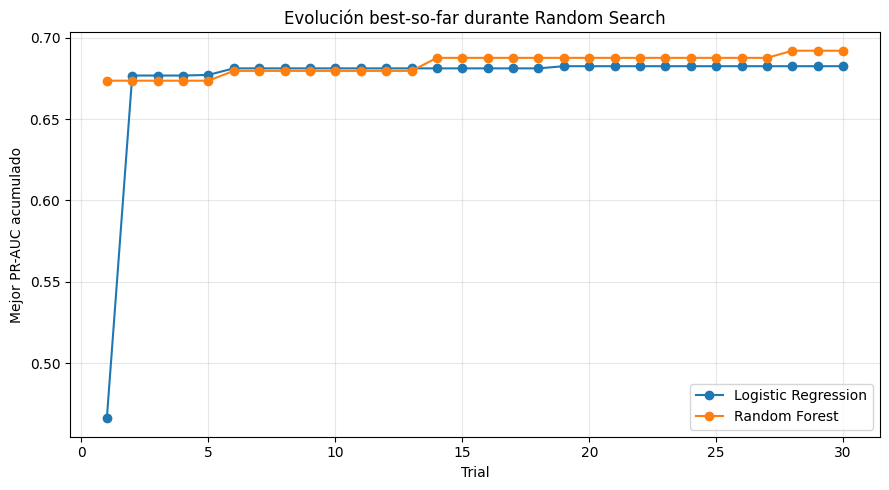

In [27]:
# =========================
# 14. Gráfico best-so-far 
# =========================

def make_best_so_far(results_df, label):
    df = results_df.copy()
    df = df.dropna(subset=["mean_test_score"]).reset_index(drop=True)

    df["trial"] = np.arange(1, len(df) + 1)
    df["best_so_far"] = df["mean_test_score"].cummax()
    df["model_family"] = label

    return df[["trial", "mean_test_score", "best_so_far", "model_family"]]

best_lr_curve = make_best_so_far(lr_results, "Logistic Regression")
best_rf_curve = make_best_so_far(rf_results, "Random Forest")

plt.figure(figsize=(9, 5))

if not best_lr_curve.empty:
    plt.plot(
        best_lr_curve["trial"],
        best_lr_curve["best_so_far"],
        marker="o",
        label="Logistic Regression"
    )

if not best_rf_curve.empty:
    plt.plot(
        best_rf_curve["trial"],
        best_rf_curve["best_so_far"],
        marker="o",
        label="Random Forest"
    )

plt.xlabel("Trial")
plt.ylabel("Mejor PR-AUC acumulado")
plt.title("Evolución best-so-far durante Random Search")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGS_DIR / "week8_best_so_far_random_search.png",
    dpi=150
)

plt.show()

# 15. Selección de configuración ganadora

Después de comparar múltiples configuraciones mediante Random Search y validación estratificada, se seleccionó la mejor configuración utilizando PR-AUC como métrica principal.

## Configuración ganadora

Modelo:

- Random Forest

Mejor PR-AUC de validación cruzada:

- 0.692

Features seleccionadas:

- lag_sent_1
- lag_sent_2

Parámetros óptimos:

- max_depth = 4
- max_features = None
- min_samples_leaf = 1
- min_samples_split = 4
- n_estimators = 54

## Interpretación

El resultado indica que la información más útil para predecir la dirección futura del USD/PEN proviene del sentimiento reciente.

La incorporación de únicamente dos variables temporales (lag_sent_1 y lag_sent_2) fue suficiente para obtener el mejor desempeño.

Variables más complejas asociadas a volumen, composición del sentimiento, tendencia y volatilidad no lograron mejorar consistentemente la métrica principal.

## Decisión

Se selecciona Random Forest con las features lag_sent_1 y lag_sent_2 como configuración candidata para evaluación final sobre el conjunto holdout.

In [24]:
# =========================
# 15. Selección de configuración ganadora
# =========================

import json
import joblib
from datetime import datetime

best_lr_score = random_search_lr.best_score_
best_rf_score = random_search_rf.best_score_

print("Mejor PR-AUC Logistic Regression:", best_lr_score)
print("Mejor PR-AUC Random Forest:", best_rf_score)

if best_lr_score >= best_rf_score:
    winner_family = "LogisticRegression"
    winner_model = random_search_lr.best_estimator_
    winner_score = best_lr_score
    winner_params = random_search_lr.best_params_
else:
    winner_family = "RandomForest"
    winner_model = random_search_rf.best_estimator_
    winner_score = best_rf_score
    winner_params = random_search_rf.best_params_

winner_summary = {
    "winner_family": winner_family,
    "winner_score_pr_auc_cv": float(winner_score),
    "winner_params": winner_params,
    "features": best_features,
    "central_metric": "PR-AUC / Average Precision",
    "validation": "StratifiedKFold complementario",
    "random_seed": RANDOM_SEED,
    "generated_at": datetime.now().isoformat()
}

print("\nConfiguración ganadora:")
print("Modelo:", winner_family)
print("PR-AUC CV:", winner_score)
print("Features:", best_features)
print("Parámetros:")
print(winner_params)

winner_config_path = LOGS_DIR / "week8_winner_config.json"

with open(winner_config_path, "w", encoding="utf-8") as f:
    json.dump(winner_summary, f, indent=2, ensure_ascii=False)

model_path = ARTIFACTS_DIR / "week8_best_model.joblib"
joblib.dump(winner_model, model_path)

print("\nConfiguración guardada en:", winner_config_path)
print("Modelo ganador guardado en:", model_path)

Mejor PR-AUC Logistic Regression: 0.6825241593011201
Mejor PR-AUC Random Forest: 0.6920481068949206

Configuración ganadora:
Modelo: RandomForest
PR-AUC CV: 0.6920481068949206
Features: ['lag_sent_1', 'lag_sent_2']
Parámetros:
{'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 54}

Configuración guardada en: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\logs\week8_winner_config.json
Modelo ganador guardado en: C:\Users\Thomy\Cursos\Proyecto_1\Proyecto_Tesis_1\news-sentiment-pipeline\data\artifacts\week8_best_model.joblib


# 16. Evaluación holdout del modelo ganador

Una vez seleccionada la mejor configuración mediante validación cruzada, se realizó una evaluación final utilizando un conjunto holdout completamente separado.

Este conjunto no participó en ninguna etapa de entrenamiento, validación o búsqueda de hiperparámetros.

## Resultados obtenidos

| Métrica | Valor |
|----------|----------|
| Accuracy | 0.444 |
| F1 Binary | 0.444 |
| Precision | 0.750 |
| Recall | 0.316 |
| PR-AUC | 0.779 |

## Matriz de confusión

Predicciones correctas:

- DOWN correctamente identificados: 6
- UP correctamente identificados: 6

Errores:

- DOWN clasificados como UP: 2
- UP clasificados como DOWN: 13

## Interpretación

El modelo muestra una precisión relativamente alta (0.75), lo que significa que cuando predice una subida del USD/PEN suele acertar.

Sin embargo, el recall es bajo (0.316), indicando que muchas subidas reales no fueron detectadas.

Esto sugiere que el modelo es conservador al emitir señales positivas.

## Comparación con validación cruzada

Durante la validación cruzada se obtuvo:

- PR-AUC ≈ 0.69

En holdout se obtuvo:

- PR-AUC ≈ 0.78

La diferencia puede atribuirse al tamaño reducido del dataset y a la variabilidad natural entre particiones.

## Conclusión

La configuración ganadora demuestra capacidad predictiva superior al baseline y logra capturar parte de la relación entre sentimiento agregado y dirección futura del USD/PEN.

No obstante, todavía existe margen de mejora en sensibilidad (recall), por lo que futuras iteraciones deberán explorar nuevas variables explicativas y estrategias de modelado.

In [25]:
# =========================
# 16. Evaluación holdout del ganador
# =========================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

X_train = train_df[best_features].copy()
y_train = train_df["target_up"].astype(int).copy()

X_test = test_df[best_features].copy()
y_test = test_df["target_up"].astype(int).copy()

# Reentrenar ganador usando solo TRAIN temporal
start = time.time()
winner_model.fit(X_train, y_train)
elapsed_holdout = time.time() - start

y_pred_winner = winner_model.predict(X_test)
y_score_winner = winner_model.predict_proba(X_test)[:, 1]

winner_holdout_metrics = {
    "model_family": winner_family,
    "features": ", ".join(best_features),
    "accuracy": accuracy_score(y_test, y_pred_winner),
    "f1_binary": f1_score(y_test, y_pred_winner, zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred_winner, average="weighted", zero_division=0),
    "precision": precision_score(y_test, y_pred_winner, zero_division=0),
    "recall": recall_score(y_test, y_pred_winner, zero_division=0),
    "pr_auc": average_precision_score(y_test, y_score_winner),
    "elapsed_seconds": elapsed_holdout,
    "n_train": len(y_train),
    "n_test": len(y_test)
}

winner_holdout_df = pd.DataFrame([winner_holdout_metrics])

display(winner_holdout_df)

print("Matriz de confusión:")
cm = confusion_matrix(y_test, y_pred_winner)
display(pd.DataFrame(
    cm,
    index=["Real_DOWN_0", "Real_UP_1"],
    columns=["Pred_DOWN_0", "Pred_UP_1"]
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_winner, zero_division=0))

winner_holdout_df.to_csv(
    LOGS_DIR / "week8_winner_holdout_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

,model_family,features,accuracy,f1_binary,f1_weighted,precision,recall,pr_auc,elapsed_seconds,n_train,n_test
0,RandomForest,"lag_sent_1, lag_sent_2",0.444444,0.444444,0.444444,0.75,0.315789,0.778794,0.041559,61,27


Matriz de confusión:


,Pred_DOWN_0,Pred_UP_1
Real_DOWN_0,6,2
Real_UP_1,13,6



Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.75      0.44         8
           1       0.75      0.32      0.44        19

    accuracy                           0.44        27
   macro avg       0.53      0.53      0.44        27
weighted avg       0.62      0.44      0.44        27

